In [1]:
import jax
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
from coppuccino.hdr import compute_injection_hdr
import corner

%load_ext autoreload
%autoreload 2

### Load feather files for LISA galactic binary from lisacattools

In [2]:
df = pd.read_feather('/Users/aaron/Documents/GitHub/coppuccino/examples/data/LDC0009146021_posterior.feather')
df_inj = pd.read_feather('/Users/aaron/Documents/GitHub/coppuccino/examples/data/LDC0009146021_injections.feather')

### Wrap the injection polarization angle to match prior of global fit

In [3]:
def wrap_polarization_angle(df: pd.DataFrame) -> pd.DataFrame:
    """
    Wrap the polarization angle to be between 0 and pi.
    """
    theta = df["Polarization"].to_numpy().squeeze()
    wrapped = np.abs(np.angle(np.exp(1j * theta)))
    df["Polarization"] = wrapped
    return df

wrap_polarization_angle(df_inj)

,Name,Amplitude,Ecliptic Latitude,Ecliptic Longitude,Frequency,Frequency Derivative,Inclination,Initial Phase,Polarization,SNR,Detached
0,14243782.0,1.927624e-23,0.078460,1.481040,0.000915,7.268414e-19,2.497675,2.544726,1.028365,2.669257,1
1,5710781.0,2.924891e-23,0.655874,5.076941,0.000915,7.535848e-19,2.453736,0.818838,3.096193,3.769661,1
2,1897944.0,1.630765e-22,0.611744,5.401896,0.000915,1.771697e-18,2.575621,0.677613,1.332100,22.895463,1
3,20548331.0,4.310133e-23,-0.065086,4.660957,0.000915,3.480832e-18,1.182964,5.240223,1.564026,3.510039,1


### Choose binary parameters to use in the fit

In [4]:
binary_parameters = ['Frequency', 'Amplitude', 'Inclination',
                              'Initial Phase', 'Ecliptic Latitude',
                              'Ecliptic Longitude', 'Polarization',
                              'Frequency Derivative']

samples = df[binary_parameters].to_numpy()
injection_params = df_inj[binary_parameters].to_numpy()

### Fit the flow and compute 8D HDR of the injected parameters

In [5]:
hdrs, flow = compute_injection_hdr(samples, injection_params, return_flow=True)

 39%|███▉      | 155/400 [00:11<00:18, 13.35it/s, train=7.35, val=7.73 (Max patience reached)]


### Display full distributional HDR values for each of the 4 injections; HDRs < 1 are within the support of the posterior

In [6]:
hdrs

array([1.     , 1.     , 0.99939, 1.     ])

### We can sample the flow and look at how it did

In [7]:
flow_samples, lp = flow.sample_and_log_prob(jax.random.key(42), (len(samples),))

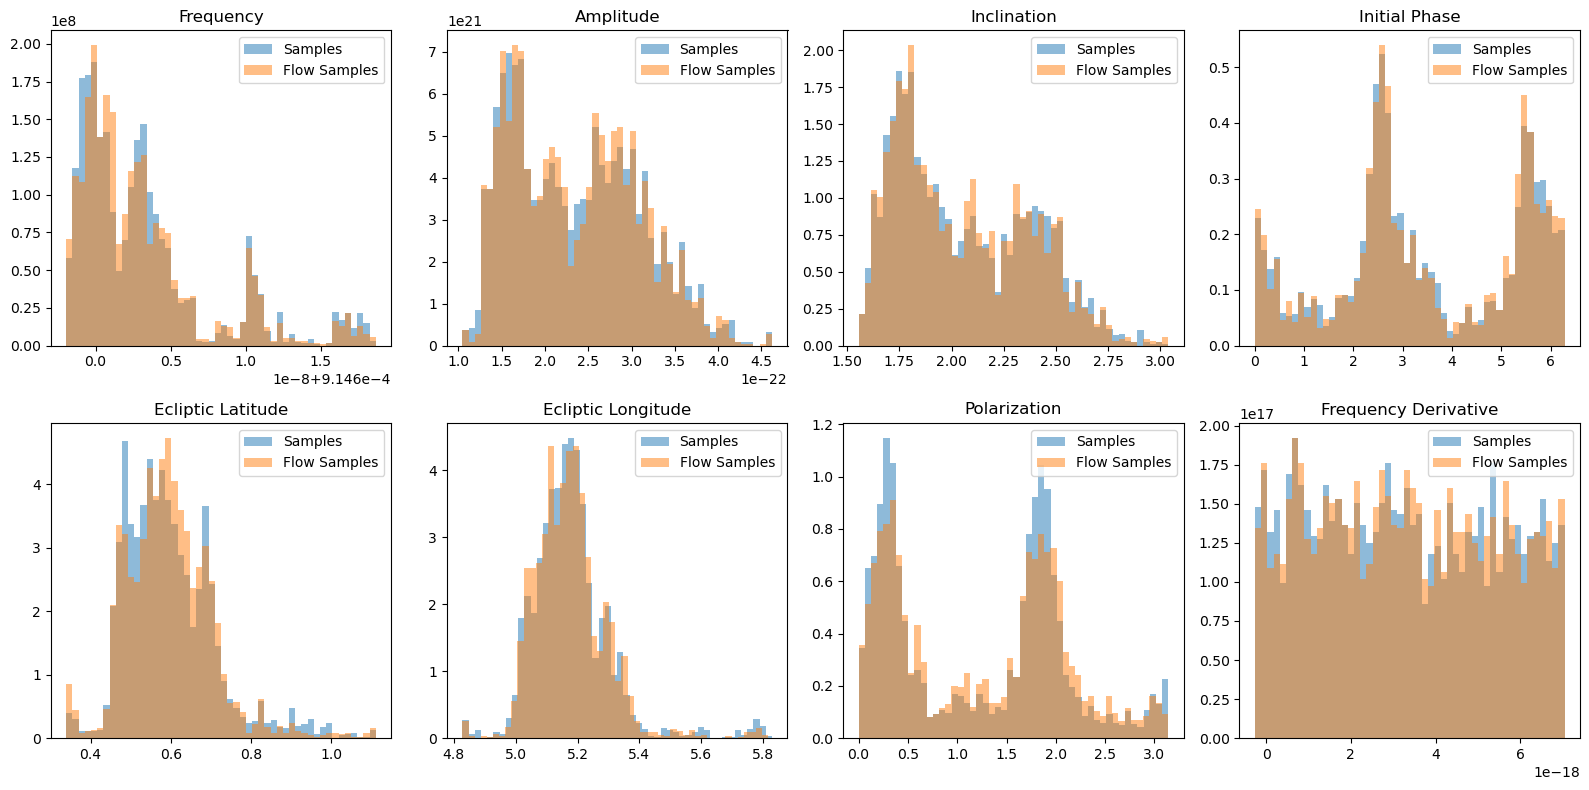

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flatten()):
    ax.hist(samples[:, i], bins=50, density=True, alpha=0.5, label='Samples')
    ax.hist(flow_samples[:, i], bins=50, density=True, alpha=0.5, label='Flow Samples')
    ax.set_title(binary_parameters[i])
    ax.legend()
plt.tight_layout()
plt.show()

### Check the corner plot to make sure we've captured the correlations

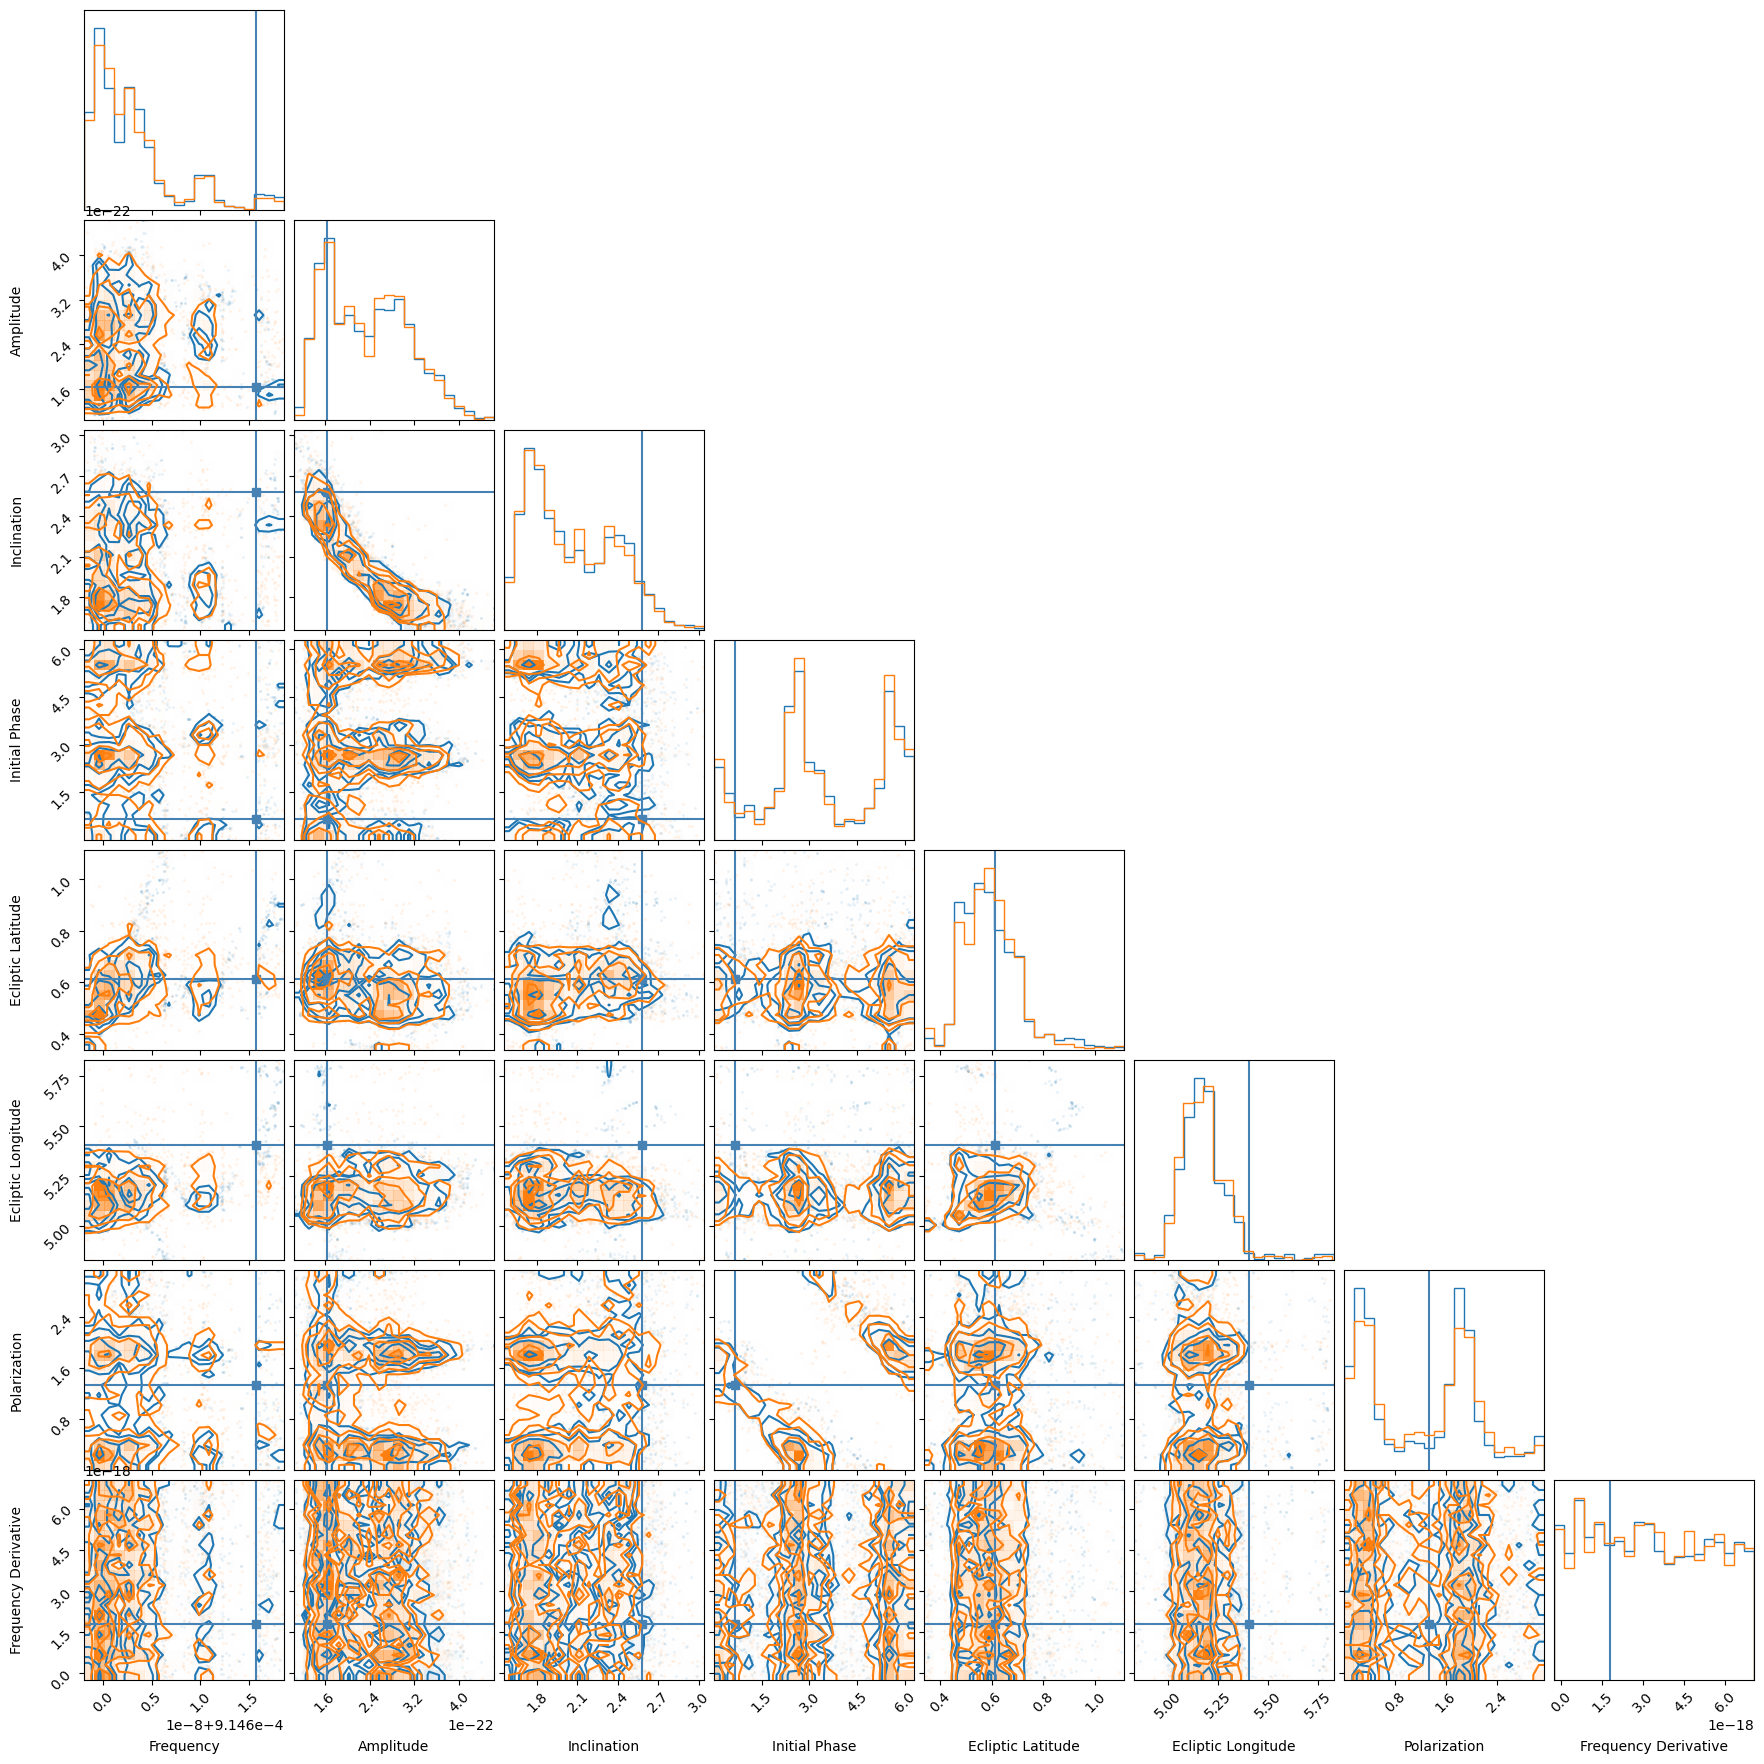

In [9]:
fig = corner.corner(samples, labels=binary_parameters, truths=injection_params[2], color='C0', hist_kwargs={'density': True})
corner.corner(np.asarray(flow_samples), labels=binary_parameters, fig=fig, color='C1', hist_kwargs={'density': True})
plt.show()